# 12 · Исследование модуля M4 (налоговый календарь)

**Что это.** M4 — детерминированный налоговый календарь (когда платятся налоги → предсказуемый отток ликвидности). **Второй по величине модуль (~29%).**

**Гипотеза:** M4 **раздут**: это детерминированный календарь, который не предсказывает стресс, но PCA даёт ему большой вес из-за регулярности и редундантности фич.

### TL;DR (спойлер — гипотеза подтвердилась жёстко)
- **Все 5 фич M4 имеют ~нулевую корреляцию с LSI** (|Spearman| < 0.06), и concurrent, и leading.
- Тяжёлая редундантность: `Seasonal_Factor_raw` ≈ `Tax_Week_Flag` (**0.99**).
- **Удаление ВСЕГО модуля меняет ранг индекса лишь на 3%** (Spearman 0.971) — прямое доказательство, что M4 не несёт реального сигнала, его 29% — артефакт PCA.
- Решение по модулю принимаем в конце (варианты в Verdict).

## Setup

In [1]:
import sys, os
from pathlib import Path
_here=Path.cwd(); _root=next((p for p in [_here,*_here.parents] if (p/'data'/'processed').is_dir()),_here)
os.chdir(_root); sys.path.insert(0,str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width',180); pd.set_option('display.max_columns',60)
import importlib
from lab import utils as u
importlib.reload(u)
print('root:',_root.name)

root: MathMode_LiquidityCatchers_RuLiquiditySentinel


In [2]:
d=u.load_final_dataset(); base_wl=u.available_whitelist(d)
m4=[c for c in base_wl if c.startswith('m4')]
art_A=u.fit_lsi_like_model(d,base_wl); lsi=art_A['lsi']; lsiS=pd.Series(lsi,index=pd.to_datetime(d['date']))
def shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return {m.upper():round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]==m]].sum(1).mean()),1) for m in ['m1','m2','m3','m4','m5']}
print('M4 whitelist (%d):'%len(m4),m4)
print('Текущие доли:',shares(art_A))

M4 whitelist (5): ['m4_Tax_Week_Flag', 'm4_Tax_Day_Strict', 'm4_MAD_tax_pressure', 'm4_MAD_tax_proximity', 'm4_Seasonal_Factor_raw']
Текущие доли: {'M1': 37.0, 'M2': 4.7, 'M3': 10.7, 'M4': 29.2, 'M5': 18.3}


## 1. Сырые данные M4 (детерминированный календарь)

`m4_dataset.csv` — дневной налоговый календарь. Это **не рыночные данные**, а расписание: счётчики налоговых событий, дни до/после платежа, флаги конца квартала/года.

строк: 4733 | диапазон: 2014-01-15 -> 2026-12-30


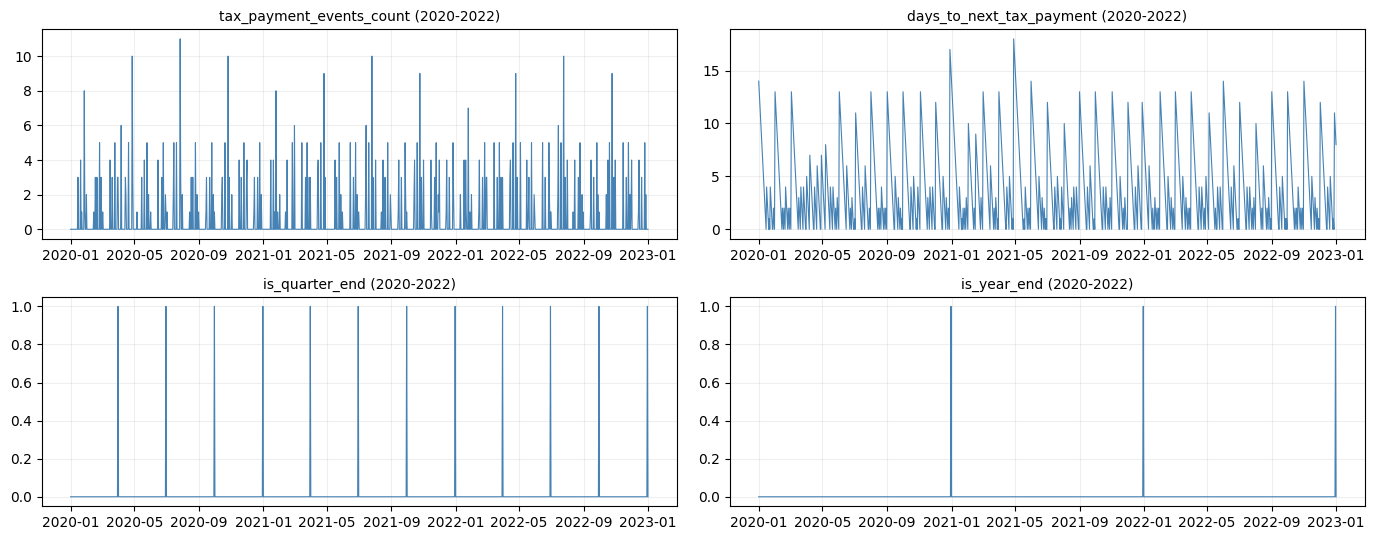

Видно: идеально регулярный «пилообразный» паттерн — повторяется каждый месяц, без связи с рынком.


In [3]:
raw,dcx=u.load_raw_csv('m4_dataset.csv')
print('строк:',len(raw),'| диапазон:',raw[dcx].min().date(),'->',raw[dcx].max().date())
cols=['tax_payment_events_count','days_to_next_tax_payment','is_quarter_end','is_year_end']
fig,axes=plt.subplots(2,2,figsize=(14,5.5))
sub=raw[(raw[dcx]>='2020-01-01')&(raw[dcx]<='2023-01-01')]  # 3 года для читаемости
for ax,c in zip(axes.ravel(),cols):
    if c in raw.columns: ax.plot(sub[dcx],pd.to_numeric(sub[c],errors='coerce'),lw=.8,color='steelblue'); ax.set_title(c+' (2020-2022)',fontsize=10); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()
print('Видно: идеально регулярный «пилообразный» паттерн — повторяется каждый месяц, без связи с рынком.')

## 2. Фичи M4 и их частоты

| фича | смысл |
|---|---|
| `m4_Tax_Week_Flag` | идёт налоговая неделя (max из pre/active/post) |
| `m4_Tax_Day_Strict` | день (±1) ключевого платежа |
| `m4_MAD_tax_pressure` | MAD интенсивности налоговых событий (кварт./год. пики) |
| `m4_MAD_tax_proximity` | MAD близости к платежу (exp-расстояние) |
| `m4_Seasonal_Factor_raw` | сезонный множитель [1.0..1.4] |

In [4]:
rows=[]
for c in m4:
    s=pd.to_numeric(d[c],errors='coerce'); isflag=s.dropna().isin([0,1]).all()
    rows.append({'feature':c,'Sp_LSI':round(u.spearman(s,lsi),3),'share==1':round(float((s==1).mean()),2) if isflag else None,
                 'unchanged':round(float((s.diff()==0).mean()),3),'std':round(float(s.std()),3)})
display(pd.DataFrame(rows))
print('Tax_Week_Flag срабатывает 72%% времени — это уже не «флаг события», а почти постоянный фон.')

,feature,Sp_LSI,share==1,unchanged,std
0,m4_Tax_Week_Flag,0.055,0.72,0.897,0.449
1,m4_Tax_Day_Strict,-0.011,0.49,0.764,0.500
2,m4_MAD_tax_pressure,-0.006,NaN,0.599,2.117
3,m4_MAD_tax_proximity,-0.006,NaN,0.176,1.492
4,m4_Seasonal_Factor_raw,0.052,NaN,0.876,0.069


Tax_Week_Flag срабатывает 72%% времени — это уже не «флаг события», а почти постоянный фон.


## 3. Главное: есть ли вообще сигнал? (Spearman с LSI, concurrent + leading)

In [5]:
print('Concurrent + leading Spearman с LSI:')
for c in m4:
    s=pd.to_numeric(d[c],errors='coerce').values
    lead=' '.join('T+%d=%+.3f'%(h,u.spearman(s,lsiS.shift(-h).values)) for h in [0,3,7,14])
    print(f'  {c:24s} {lead}')
print()
print('ВЫВОД: ни одна фича M4 не коррелирует с LSI ни на одном горизонте (|Sp|<0.06).')
print('Налоги платятся по расписанию независимо от кризисов (2014/2022 — это FX/геополитика, не налоги).')

Concurrent + leading Spearman с LSI:
  m4_Tax_Week_Flag         T+0=+0.055 T+3=+0.050 T+7=+0.060 T+14=+0.077
  m4_Tax_Day_Strict        T+0=-0.011 T+3=-0.009 T+7=+0.008 T+14=+0.014
  m4_MAD_tax_pressure      T+0=-0.006 T+3=+0.003 T+7=+0.011 T+14=+0.011
  m4_MAD_tax_proximity     T+0=-0.006 T+3=-0.008 T+7=+0.003 T+14=+0.007
  m4_Seasonal_Factor_raw   T+0=+0.052 T+3=+0.047 T+7=+0.058 T+14=+0.076

ВЫВОД: ни одна фича M4 не коррелирует с LSI ни на одном горизонте (|Sp|<0.06).
Налоги платятся по расписанию независимо от кризисов (2014/2022 — это FX/геополитика, не налоги).


## 4. Редундантность внутри M4

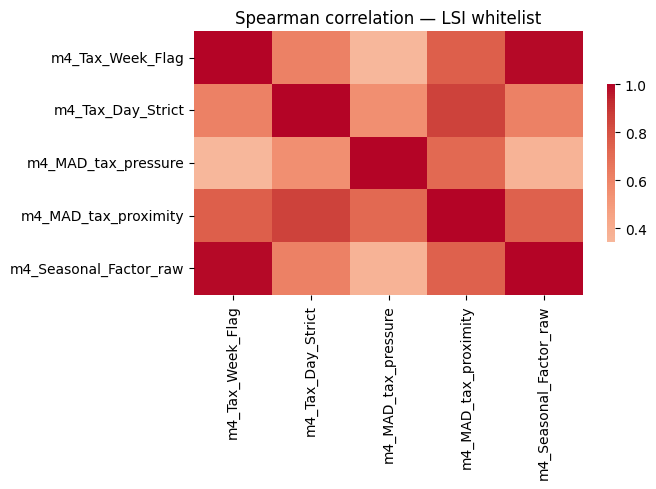

Seasonal_Factor_raw ~ Tax_Week_Flag = 0.987 (почти идентичны)


In [6]:
fig,ax,corr=u.correlation_heatmap(d,m4,method='spearman',figsize=(7,5)); plt.show()
print('Seasonal_Factor_raw ~ Tax_Week_Flag =',round(u.spearman(d.m4_Seasonal_Factor_raw,d.m4_Tax_Week_Flag),3),'(почти идентичны)')

## 5. Ablation — что будет, если урезать/убрать M4

In [7]:
non_m4=[x for x in base_wl if not x.startswith('m4')]
sets=[('A current (5)',base_wl),
      ('B drop Seasonal-dup (4)',non_m4+['m4_Tax_Week_Flag','m4_Tax_Day_Strict','m4_MAD_tax_pressure','m4_MAD_tax_proximity']),
      ('C keep pressure+week (2)',non_m4+['m4_Tax_Week_Flag','m4_MAD_tax_pressure']),
      ('D keep MAD_tax_pressure (1)',non_m4+['m4_MAD_tax_pressure']),
      ('E drop M4 совсем (0)',non_m4)]
rows=[]
for nm,cols in sets:
    a=u.fit_lsi_like_model(d,cols); s=shares(a)
    rows.append({'set':nm,'M4%':s['M4'],'Sp_vs_A':round(u.spearman(a['lsi'],lsi),4),'M1%':s['M1'],'M2%':s['M2'],'M3%':s['M3'],'M5%':s['M5']})
display(pd.DataFrame(rows))
print('Даже полное удаление M4 (E) даёт Sp=0.971 — ранг почти не меняется. Но 29%% уходит в основном в M1')
print('(37->51%%) -> нужен совместный фикс с M1/M2/M3, иначе M1 переконцентрируется.')

,set,M4%,Sp_vs_A,M1%,M2%,M3%,M5%
0,A current (5),29.2,1.0000,37.0,4.7,10.7,18.3
1,B drop Seasonal-dup (4),22.2,0.9943,39.4,5.4,12.1,20.9
2,C keep pressure+week (2),13.1,0.9861,43.5,5.8,13.7,23.8
3,D keep MAD_tax_pressure (1),7.1,0.9681,47.1,6.6,14.4,24.8
4,E drop M4 совсем (0),0.0,0.9710,50.8,7.0,15.1,27.1


Даже полное удаление M4 (E) даёт Sp=0.971 — ранг почти не меняется. Но 29%% уходит в основном в M1
(37->51%%) -> нужен совместный фикс с M1/M2/M3, иначе M1 переконцентрируется.


## Verdict по M4 — решение за тобой

**Факты:**
- M4 = детерминированный календарь; **нулевая корреляция со стрессом** (все фичи |Sp|<0.06, concurrent и leading).
- 29% важности — **артефакт PCA**: 5 редундантных регулярных фич создают сильный коррелированный кластер.
- Удаление всего модуля меняет ранг на 3% (Sp 0.971) → реального вклада в детекцию стресса нет.
- Экономически налоги **реально** изымают ликвидность, но **по расписанию**, а не в привязке к кризисам.

**Варианты решения:**
| вариант | M4 share | плюсы | минусы |
|---|---|---|---|
| **1. Drop полностью** | 0% | честно: нет сигнала — нет веса; убирает 29% артефакта | теряем «налоговый контекст» как фичу |
| **2. Свести к 1 фиче** (`MAD_tax_pressure`) | ~7% | минимальный контекст кварт./год. пиков | даже она Sp≈0 |
| **3. Вынести M4 из PCA в overlay** | 0% в PCA | детерминированный множитель/контекст поверх LSI (амплификация в налоговые недели), не конкурирует за attribution | требует доработки логики вывода |

**Моя рекомендация:** вариант **3** концептуально самый честный (детерминированный календарь — это контекст/модулятор, а не аномалия), но он сложнее в реализации. Быстрый и чистый — вариант **1** (drop из feature-matrix), при этом сам по себе `Tax_Week_Flag` можно оставить как метку для дашборда/объяснения, но НЕ как PCA-фичу. Вариант 2 — компромисс, если хочется оставить хоть какой-то след M4 в индексе.

_Важно: при любом варианте 29% перераспределятся (в основном в M1), поэтому решение по M4 нужно применять ВМЕСТЕ с фиксом M1 (редундантность) и honest M2/M3 — тогда баланс будет здоровым._

---
### Р Е Ш Е Н И Е (принято): вариант 3 — overlay
M4 **убирается из PCA feature-matrix** (все 5 фич уходят из whitelist Global и Local) и возвращается отдельным **детерминированным слоем-контекстом** поверх LSI:
- `Tax_Week_Flag` / близость к платежу — как **метаданные/контекст** в выводе и на дашборде (аналитик видит «идёт налоговая неделя»), но НЕ как PCA-фича.
- (опционально) лёгкая амплификация статуса/LSI в пик налогов — но т.к. эмпирически M4 имеет **нулевую** корреляцию со стрессом, любая амплификация это **бизнес-допущение**, не data-driven; по умолчанию консервативно (контекст без изменения числа LSI).

**Для Phase B:** удалить `m4_*` из `LSI_FEATURE_CANDIDATES`; добавить tax-контекст в ответ `get_lsi_prediction` отдельным полем; 29% attribution честно перераспределятся между M1/M2/M3/M5 (применять вместе с фиксом редундантности M1).